# Assignment 2: Mastering Big Data Handling
### SECP3133 – High Performance Data Processing

---

**Dataset:** NYC Parking Tickets  
**Source:** [Kaggle – NYC Parking Tickets](https://www.kaggle.com/datasets/new-york-city/nyc-parking-tickets)  
**Libraries Used:** Pandas · Dask · Polars

---
## Step 0: Environment Setup

Here we install any libraries that are not pre-installed in Google Colab, then import everything we need.  
We also connect to Google Drive so we can access our dataset.


In [21]:
import pandas as pd
import polars as pl
import dask
import dask.dataframe as dd
dask.config.set({"dataframe.convert-string": False})
import re

import time
import psutil
import tracemalloc
import os
import gc  # garbage collector to free memory


# Define the file_path list to include all extracted CSV files
file_path = 'Parking_Violations_Issued_-_Fiscal_Year_2017.csv'

In [22]:
# -------------------------------------------------------
# Performance Measurement Helper — reused by all strategies
# Measures: memory usage, execution time, CPU usage,
#           throughput, and peak memory usage.
# -------------------------------------------------------

def measure_performance(func, rows=None):
    """
    Runs func() and measures five performance metrics.

    Parameters
    ----------
    func : callable  — wrap your operation in a lambda or inner function
    rows : int, optional — number of rows processed; used to compute throughput

    Returns
    -------
    result  : the return value of func()
    metrics : dict with keys:
        memory_mb       — RSS memory in use after func (MB)
        execution_time  — wall-clock time in seconds
        cpu_percent     — CPU % used by this process during func
        throughput      — rows / second (None when rows is not given)
        peak_memory_mb  — peak memory allocated during func (MB)
    """
    process = psutil.Process(os.getpid())
    process.cpu_percent(interval=None)   # first call always returns 0; discard

    tracemalloc.start()
    start_time = time.time()

    result = func()

    end_time       = time.time()
    cpu_usage      = process.cpu_percent(interval=None)
    _, peak_mem    = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    execution_time = end_time - start_time

    metrics = {
        'memory_mb'      : process.memory_info().rss / (1024 ** 2),
        'execution_time' : execution_time,
        'cpu_percent'    : cpu_usage,
        'throughput'     : (rows / execution_time)
                           if (rows is not None and execution_time > 0)
                           else None,
        'peak_memory_mb' : peak_mem / (1024 ** 2),
    }
    return result, metrics


def print_metrics(metrics):
    """Print all five performance metrics."""
    print("=========================================")
    print(f"  Memory usage      : {metrics['memory_mb']:.2f} MB")
    print(f"  Execution time    : {metrics['execution_time']:.2f} seconds")
    print(f"  CPU usage         : {metrics['cpu_percent']:.1f}%")
    if metrics['throughput'] is not None:
        print(f"  Throughput        : {metrics['throughput']:,.0f} rows/sec")
    print(f"  Peak memory usage : {metrics['peak_memory_mb']:.2f} MB")
    print("=========================================")


print("measure_performance and print_metrics defined successfully!")


measure_performance and print_metrics defined successfully!


### Task 2: Load and Inspect the Dataset

In this part, we will load the dataset to inspect on several of its informations including:
- Number of rows and columns
- data type of each columns
- Missing values per column
- Preview of first 5 rows

In [3]:
# Full load using pandas dataframe

df = pd.read_csv(file_path, low_memory=True)

C:\Users\user\AppData\Local\Temp\ipykernel_28624\2532492198.py:3: DtypeWarning: Columns (0: Issuer Squad, 1: Violation Post Code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, low_memory=True)


In [4]:
# Show column names and the data types

print(df.dtypes)

Summons Number                         int64
Plate ID                                 str
Registration State                       str
Plate Type                               str
Issue Date                               str
Violation Code                         int64
Vehicle Body Type                        str
Vehicle Make                             str
Issuing Agency                           str
Street Code1                           int64
Street Code2                           int64
Street Code3                           int64
Vehicle Expiration Date                int64
Violation Location                   float64
Violation Precinct                     int64
Issuer Precinct                        int64
Issuer Code                            int64
Issuer Command                           str
Issuer Squad                          object
Violation Time                           str
Time First Observed                      str
Violation County                         str
Violation 

In [5]:
# Show missing values per columns

print(df.isnull().sum())

Summons Number                              0
Plate ID                                  728
Registration State                          0
Plate Type                                  0
Issue Date                                  0
Violation Code                              0
Vehicle Body Type                       42711
Vehicle Make                            73050
Issuing Agency                              0
Street Code1                                0
Street Code2                                0
Street Code3                                0
Vehicle Expiration Date                     0
Violation Location                    2072400
Violation Precinct                          0
Issuer Precinct                             0
Issuer Code                                 0
Issuer Command                        2062645
Issuer Squad                          2063541
Violation Time                             63
Time First Observed                   9962281
Violation County                  

In [6]:
# Preview the first 5 rows of the dataset

print(df.head())

   Summons Number Plate ID Registration State Plate Type  Issue Date  \
0      5092469481  GZH7067                 NY        PAS  07/10/2016   
1      5092451658  GZH7067                 NY        PAS  07/08/2016   
2      4006265037  FZX9232                 NY        PAS  08/23/2016   
3      8478629828  66623ME                 NY        COM  06/14/2017   
4      7868300310  37033JV                 NY        COM  11/21/2016   

   Violation Code Vehicle Body Type Vehicle Make Issuing Agency  Street Code1  \
0               7              SUBN        TOYOT              V             0   
1               7              SUBN        TOYOT              V             0   
2               5              SUBN         FORD              V             0   
3              47              REFG        MITSU              T         10610   
4              69              DELV        INTER              T         10510   

   ...  Vehicle Color  Unregistered Vehicle?  Vehicle Year  Meter Number  \
0  .

---

### Task 3: Big Data Handling Strategies

Now we apply **5 strategies** to handle the large dataset efficiently.  
Each strategy solves a specific problem you face when working with big data.

| # | Strategy | Problem It Solves |
|---|---|---|
| 1 | Load Less Data | Loading unnecessary columns wastes RAM |
| 2 | Chunking | File is too large to load all at once |
| 3 | Data Type Optimisation | Default data types use too much memory |
| 4 | Sampling | Full data takes too long for exploration |
| 5 | Parallel Processing | Single-threaded Pandas is slow on big data |

---

### Strategy 1: Load Less Data

Instead of loading all 43 columns, we only load the columns we actually need.
This immediately reduces memory consumption and speeds up loading time.

Key technique: usecols parameter in pd.read_csv()

In [7]:
# ---- BASELINE: Load ALL columns ----

COLUMNS_WE_NEED = [
    'Summons Number',
    'Plate ID',
    'Registration State',
    'Vehicle Make',
    'Violation Code',
    'Issue Date',
    'Vehicle Year'
]

print("BASELINE: Loading ALL columns...\n")

df_all, metrics = measure_performance(
    lambda: pd.read_csv(file_path, low_memory=True),
    rows=len(df)
)
baseline_time   = metrics['execution_time']
baseline_mem_mb = df_all.memory_usage(deep=True).sum() / (1024**2)

print(f"✓ Loaded {len(df_all):,} rows × {len(df_all.columns)} columns")
print_metrics(metrics)

# Clear memory
del df_all
gc.collect()


BASELINE: Loading ALL columns...



C:\Users\user\AppData\Local\Temp\ipykernel_28624\1680949649.py:16: DtypeWarning: Columns (0: Issuer Squad, 1: Violation Post Code) have mixed types. Specify dtype option on import or set low_memory=False.
  lambda: pd.read_csv(file_path, low_memory=True),


✓ Loaded 10,803,028 rows × 43 columns
  Memory usage      : 6428.25 MB
  Execution time    : 248.79 seconds
  CPU usage         : 98.3%
  Throughput        : 43,422 rows/sec
  Peak memory usage : 5026.08 MB


30

In [8]:
# ---- OPTIMIZED: Load ONLY selected columns ----

print("OPTIMIZED: Loading ONLY selected columns...\n")

df_less, metrics = measure_performance(
    lambda: pd.read_csv(file_path, usecols=COLUMNS_WE_NEED, low_memory=True),
    rows=len(df)
)
optimized_time   = metrics['execution_time']
optimized_mem_mb = df_less.memory_usage(deep=True).sum() / (1024**2)

print(f"✓ Loaded {len(df_less):,} rows × {len(df_less.columns)} columns")
print_metrics(metrics)


OPTIMIZED: Loading ONLY selected columns...

✓ Loaded 10,803,028 rows × 7 columns
  Memory usage      : 2068.93 MB
  Execution time    : 49.51 seconds
  CPU usage         : 99.2%
  Throughput        : 218,219 rows/sec
  Peak memory usage : 1589.38 MB


In [9]:
# ---- COMPARISON ----

print("COMPARISON:\n")
print(f"Memory reduction: {baseline_mem_mb:.2f} MB → {optimized_mem_mb:.2f} MB")
print(f"Savings: {((baseline_mem_mb - optimized_mem_mb) / baseline_mem_mb * 100):.1f}%")
print(f"Time reduction: {baseline_time:.2f}s → {optimized_time:.2f}s")
print(f"Speed improvement: {((baseline_time - optimized_time) / baseline_time * 100):.1f}% faster")

COMPARISON:

Memory reduction: 5356.37 MB → 821.67 MB
Savings: 84.7%
Time reduction: 248.79s → 49.51s
Speed improvement: 80.1% faster


---

### Strategy 2: Chunking
Process large files in smaller pieces (chunks) to avoid loading everything
into memory at once. Perfect for aggregations, filtering, or transformations.

Key technique: chunksize parameter in pd.read_csv()


In [10]:
CHUNK_SIZE = 100000  # Process 100,000 rows at a time

print("Loading data in chunks...\n")

def _chunk_process():
    state_counts       = {}
    chunk_num          = 0
    total_rows         = 0
    for chunk in pd.read_csv(file_path, chunksize=CHUNK_SIZE, low_memory=False):
        chunk_num  += 1
        total_rows += len(chunk)
        chunk_state_counts = chunk['Registration State'].value_counts()
        for state, count in chunk_state_counts.items():
            state_counts[state] = state_counts.get(state, 0) + count
        if chunk_num % 5 == 0:
            print(f"Processed chunk {chunk_num}: {total_rows:,} rows ...")
    return chunk_num, total_rows, state_counts

(chunk_number, total_rows_processed, state_counts), metrics = measure_performance(_chunk_process, rows=len(df))
chunk_time = metrics['execution_time']

print(f"\n3. Chunking Results:")
print(f"Total chunks processed: {chunk_number}")
print(f"Total rows processed: {total_rows_processed:,}")
print_metrics(metrics)
print(f"Average time per chunk: {chunk_time / chunk_number:.2f} seconds")

print("\n5. Key Benefit of Chunking:")
print(f"✓ Processed {total_rows_processed:,} rows without loading all at once")
print(f"✓ Peak memory only {metrics['peak_memory_mb']:.2f} MB (vs full load)")
print(f"✓ Can process files LARGER than available RAM")


Loading data in chunks...

Processed chunk 5: 500,000 rows ...
Processed chunk 10: 1,000,000 rows ...
Processed chunk 15: 1,500,000 rows ...
Processed chunk 20: 2,000,000 rows ...
Processed chunk 25: 2,500,000 rows ...
Processed chunk 30: 3,000,000 rows ...
Processed chunk 35: 3,500,000 rows ...
Processed chunk 40: 4,000,000 rows ...
Processed chunk 45: 4,500,000 rows ...
Processed chunk 50: 5,000,000 rows ...
Processed chunk 55: 5,500,000 rows ...
Processed chunk 60: 6,000,000 rows ...
Processed chunk 65: 6,500,000 rows ...
Processed chunk 70: 7,000,000 rows ...
Processed chunk 75: 7,500,000 rows ...
Processed chunk 80: 8,000,000 rows ...
Processed chunk 85: 8,500,000 rows ...
Processed chunk 90: 9,000,000 rows ...
Processed chunk 95: 9,500,000 rows ...
Processed chunk 100: 10,000,000 rows ...
Processed chunk 105: 10,500,000 rows ...

3. Chunking Results:
Total chunks processed: 109
Total rows processed: 10,803,028
  Memory usage      : 2039.30 MB
  Execution time    : 228.67 seconds


---

### Strategy 3 : Data Type Optimisation



In [23]:
# Load ALL columns with 200,000 rows for testing
print("Loading 200,000 rows with ALL columns and default types...\n")

df_original, metrics = measure_performance(
    lambda: pd.read_csv(file_path, nrows=200000, low_memory=True)
)
original_memory = df_original.memory_usage(deep=True).sum() / (1024**2)
print_metrics(metrics)


Loading 200,000 rows with ALL columns and default types...

  Memory usage      : 277.21 MB
  Execution time    : 4.82 seconds
  CPU usage         : 94.6%
  Peak memory usage : 94.00 MB


In [24]:
print("\nAnalyzing columns for optimization...")
print("\nColumn-by-column analysis:\n")
for col in df_original.columns:
    dtype = df_original[col].dtype
    unique_count = df_original[col].nunique()
    mem_mb = df_original[col].memory_usage(deep=True) / (1024**2)

    print(f"   • {col}:")
    print(f"      - Type: {dtype}, Memory: {mem_mb:.2f} MB")
    print(f"      - Unique values: {unique_count:,}")


Analyzing columns for optimization...

Column-by-column analysis:

   • Summons Number:
      - Type: int64, Memory: 1.53 MB
      - Unique values: 200,000
   • Plate ID:
      - Type: str, Memory: 2.86 MB
      - Unique values: 171,268
   • Registration State:
      - Type: str, Memory: 1.91 MB
      - Unique values: 63
   • Plate Type:
      - Type: str, Memory: 2.10 MB
      - Unique values: 58
   • Issue Date:
      - Type: str, Memory: 3.43 MB
      - Unique values: 363
   • Violation Code:
      - Type: int64, Memory: 1.53 MB
      - Unique values: 85
   • Vehicle Body Type:
      - Type: str, Memory: 2.27 MB
      - Unique values: 250
   • Vehicle Make:
      - Type: str, Memory: 2.43 MB
      - Unique values: 449
   • Issuing Agency:
      - Type: str, Memory: 1.72 MB
      - Unique values: 14
   • Street Code1:
      - Type: int64, Memory: 1.53 MB
      - Unique values: 4,238
   • Street Code2:
      - Type: int64, Memory: 1.53 MB
      - Unique values: 4,331
   • Street Code

In [25]:
dtype_map = {
    # --- Already optimized numeric ---
    'Summons Number': 'int64',
    'Violation Code': 'Int16',
    'Street Code1': 'Int32',
    'Street Code2': 'Int32',
    'Street Code3': 'Int32',
    'Vehicle Expiration Date': 'Int32',
    'Violation Location': 'float32',
    'Violation Precinct': 'Int16',
    'Issuer Precinct': 'Int16',
    'Issuer Code': 'Int32',
    'Date First Observed': 'Int32',
    'Law Section': 'Int16',
    'Unregistered Vehicle?': 'float32',
    'Vehicle Year': 'Int16',
    'Feet From Curb': 'Int16',
    'No Standing or Stopping Violation': 'float32',
    'Hydrant Violation': 'float32',
    'Double Parking Violation': 'float32',

    # --- Convert to category (LOW cardinality → big memory win) ---
    'Registration State': 'category',
    'Plate Type': 'category',
    'Vehicle Body Type': 'category',
    'Vehicle Make': 'category',
    'Issuing Agency': 'category',
    'Violation County': 'category',
    'Violation In Front Of Or Opposite': 'category',
    'Sub Division': 'category',

    # --- Keep as string (HIGH cardinality / IDs / free text) ---
    'Plate ID': 'string',
    'Issue Date': 'string',
    'Issuer Command': 'string',
    'Issuer Squad': 'string',
    'Violation Time': 'string',
    'Time First Observed': 'string',
    'House Number': 'string',
    'Street Name': 'string',
    'Intersecting Street': 'string',
    'Violation Legal Code': 'string',
    'Days Parking In Effect': 'string',
    'From Hours In Effect': 'string',
    'To Hours In Effect': 'string',
    'Vehicle Color': 'string',
    'Meter Number': 'string',
    'Violation Post Code': 'string',
    'Violation Description': 'string'
}

In [28]:
def load_fully_optimized():
    df = pd.read_csv(
        file_path,
        nrows=200000,
        dtype=dtype_map,
        low_memory=True
    )

    return df

df_optimized, metrics = measure_performance(load_fully_optimized, rows=10803028)
print_metrics(metrics)

  Memory usage      : 346.21 MB
  Execution time    : 29.25 seconds
  CPU usage         : 98.9%
  Throughput        : 369,283 rows/sec
  Peak memory usage : 28.46 MB


In [29]:
import pandas as pd

# 1. Collect data into a list of dictionaries
stats = []
for col in df_original.columns:
    mem_before = df_original[col].memory_usage(deep=True) / (1024**2)
    mem_after = df_optimized[col].memory_usage(deep=True) / (1024**2)
    
    stats.append({
        "Column": col,
        "Dtype Before": df_original[col].dtype,
        "Dtype After": df_optimized[col].dtype,
        "Memory Before (MB)": round(mem_before, 2),
        "Memory After (MB)": round(mem_after, 2),
        "Reduction (%)": f"{((mem_before - mem_after) / mem_before * 100):.1f}%"
    })

# 2. Create the summary DataFrame
df_memory_compare = pd.DataFrame(stats)

# 3. Display in VS Code / Jupyter
df_memory_compare

,Column,Dtype Before,Dtype After,Memory Before (MB),Memory After (MB),Reduction (%)
0,Summons Number,int64,int64,1.53,1.53,0.0%
1,Plate ID,str,string,2.86,2.86,0.2%
2,Registration State,str,category,1.91,0.19,89.9%
3,Plate Type,str,category,2.10,0.19,90.8%
4,Issue Date,str,string,3.43,3.43,0.0%
5,Violation Code,int64,Int16,1.53,0.57,62.5%
6,Vehicle Body Type,str,category,2.27,0.39,82.7%
7,Vehicle Make,str,category,2.43,0.40,83.5%
8,Issuing Agency,str,category,1.72,0.19,88.8%
9,Street Code1,int64,Int32,1.53,0.95,37.5%


In [31]:
# Calculate memory in MB for the original DataFrame
original_memory = df_original.memory_usage(deep=True).sum() / (1024**2)
print(f"Original memory: {original_memory:.2f} MB")

# Calculate memory in MB for the optimized DataFrame
optimized_memory = df_optimized.memory_usage(deep=True).sum() / (1024**2)
print(f"Optimized memory: {optimized_memory:.2f} MB")

memory_saved = original_memory - optimized_memory
reduction_percentage = (memory_saved / original_memory) * 100

print(f"Memory saved: {memory_saved:.2f} MB")
print(f"Reduction: {reduction_percentage:.1f}%")

Original memory: 85.18 MB
Optimized memory: 58.28 MB
Memory saved: 26.90 MB
Reduction: 31.6%


---

### Strategy 4: Sampling

In this part, we will create a sample of dataset using a subset of the fully loaded dataset's rows

In [28]:
# Sampling using pandas dataframe

_, metrics = measure_performance(
    lambda: pd.read_csv(file_path, low_memory=False, nrows=1000000),
    rows=1000000
)
print_metrics(metrics)


  Memory usage      : 1300.22 MB
  Execution time    : 21.81 seconds
  CPU usage         : 99.4%
  Throughput        : 45,853 rows/sec
  Peak memory usage : 414.12 MB


In [32]:
# Sampling using polars dataframe

_, metrics = measure_performance(
    lambda: pl.read_csv(file_path, n_rows=1000000),
    rows=1000000
)
print_metrics(metrics)


  Memory usage      : 2807.23 MB
  Execution time    : 2.81 seconds
  CPU usage         : 371.9%
  Throughput        : 356,329 rows/sec
  Peak memory usage : 0.00 MB


In [32]:
# Sampling using dask dataframe

def _dask_sample():
    df = dd.read_csv(file_path, dtype={
        'House Number': 'str',
        'Time First Observed': 'str'
    })
    return df.sample(frac=0.1)

_, metrics = measure_performance(_dask_sample)
print_metrics(metrics)


  Memory usage      : 4053.50 MB
  Execution time    : 0.71 seconds
  CPU usage         : 98.6%
  Peak memory usage : 2185.98 MB


---

### Strategy 5: Parallel Processing

For This strategy, we will use 3  different libraries which are pandas, polars and dask. We will run the same 3 operations using all 3 libraries and measure the time and memory for each:
1. Load the CSV file
2. Filter rows (only NY state plates)
3. Count violations per vehicle make

In [4]:
# Full loading the dataset into pandas dataframe

pd_times = {}

def _pandas_pipeline():
    pd_times['load_start'] = time.time()
    df = pd.read_csv(file_path, low_memory=True)
    pd_times['load_end'] = time.time()

    pd_times['filter_start'] = time.time()
    df = df[df['Registration State'] == 'NY']
    pd_times['filter_end'] = time.time()

    pd_times['count_start'] = time.time()
    df['Vehicle Make'].value_counts()
    pd_times['count_end'] = time.time()
    return df

_, metrics = measure_performance(_pandas_pipeline, rows=10803028)

pandas_load_time   = pd_times['load_end']    - pd_times['load_start']
pandas_filter_time = pd_times['filter_end']  - pd_times['filter_start']
pandas_count_time  = pd_times['count_end']   - pd_times['count_start']
pandas_total_time  = metrics['execution_time']
pandas_mem_mb      = metrics['peak_memory_mb']

print(f"Load Execution time: {pandas_load_time:.2f} seconds")
print(f"Filter execution time: {pandas_filter_time:.2f} seconds")
print(f"Count execution time: {pandas_count_time:.2f} seconds")
print_metrics(metrics)

C:\Users\user\AppData\Local\Temp\ipykernel_1896\1472330593.py:7: DtypeWarning: Columns (0: Issuer Squad, 1: Violation Post Code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, low_memory=True)


Load Execution time: 238.77 seconds
Filter execution time: 6.13 seconds
Count execution time: 0.33 seconds
  Memory usage      : 6825.22 MB
  Execution time    : 245.23 seconds
  CPU usage         : 99.0%
  Throughput        : 44,053 rows/sec
  Peak memory usage : 5026.10 MB


In [5]:
# -------------------------------------------------------
# Strategy 5b: Polars (Scalable Library 2)
# -------------------------------------------------------

polars_times = {}

def _polars_pipeline():
    polars_times['load_start'] = time.time()
    df = pl.read_csv(file_path, low_memory=True)
    polars_times['load_end'] = time.time()

    polars_times['filter_start'] = time.time()
    df = df.filter(pl.col('Registration State') == 'NY')
    polars_times['filter_end'] = time.time()

    polars_times['count_start'] = time.time()
    df.select(pl.col("Vehicle Make").value_counts())
    polars_times['count_end'] = time.time()
    return df

_, metrics = measure_performance(_polars_pipeline, rows=10803028)

polars_load_time   = polars_times['load_end']   - polars_times['load_start']
polars_filter_time = polars_times['filter_end'] - polars_times['filter_start']
polars_count_time  = polars_times['count_end']  - polars_times['count_start']
polars_total_time  = metrics['execution_time']
polars_mem_mb      = metrics['peak_memory_mb']

print(f"Load Execution time: {polars_load_time:.2f} seconds")
print(f"Filter execution time: {polars_filter_time:.2f} seconds")
print(f"Count execution time: {polars_count_time:.2f} seconds")
print_metrics(metrics)


Load Execution time: 11.86 seconds
Filter execution time: 11.02 seconds
Count execution time: 0.88 seconds
  Memory usage      : 443.41 MB
  Execution time    : 23.76 seconds
  CPU usage         : 200.3%
  Throughput        : 454,726 rows/sec
  Peak memory usage : 0.03 MB


In [6]:
# -------------------------------------------------------
# Strategy 5c: Dask (Scalable Library 3)
# -------------------------------------------------------

dask_times = {}

def _dask_pipeline():
    dask_times['load_start'] = time.time()
    df = dd.read_csv(file_path, dtype={
        'House Number': 'str',
        'Time First Observed': 'str'
    }, blocksize="32MB")
    dask_times['load_end'] = time.time()

    dask_times['filter_start'] = time.time()
    df_filtered = df[df['Registration State'] == 'NY']
    dask_times['filter_end'] = time.time()

    dask_times['count_start'] = time.time()
    result = df_filtered['Vehicle Make'].value_counts().compute()
    dask_times['count_end'] = time.time()
    return result

_, metrics = measure_performance(_dask_pipeline, rows=10803028)

dask_load_time   = dask_times['load_end']   - dask_times['load_start']
dask_filter_time = dask_times['filter_end'] - dask_times['filter_start']
dask_count_time  = dask_times['count_end']  - dask_times['count_start']
dask_total_time  = metrics['execution_time']
dask_mem_mb      = metrics['peak_memory_mb']

print(f"Load Execution time: {dask_load_time:.2f} seconds")
print(f"Filter execution time: {dask_filter_time:.2f} seconds")
print(f"Count execution time: {dask_count_time:.2f} seconds")
print_metrics(metrics)

c:\Users\user\Documents\hpdp_assignment2\.venv\Lib\site-packages\dask\dataframe\io\csv.py:76: DtypeWarning: Columns (0: Issuer Squad, 1: Violation Post Code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = reader(bio, **kwargs)
c:\Users\user\Documents\hpdp_assignment2\.venv\Lib\site-packages\dask\dataframe\io\csv.py:76: DtypeWarning: Columns (0: Issuer Squad, 1: Violation Post Code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = reader(bio, **kwargs)


Load Execution time: 0.65 seconds
Filter execution time: 0.07 seconds
Count execution time: 232.48 seconds
  Memory usage      : 760.77 MB
  Execution time    : 233.19 seconds
  CPU usage         : 116.7%
  Throughput        : 46,326 rows/sec
  Peak memory usage : 1037.84 MB


---

### Task 4: Comparative Analysis

Now we compare the three libraries side by side using:
1. A **summary table** of all metrics
2. **Bar charts** to visualise the differences
3. A **written discussion** explaining what the results mean

In [7]:
# -------------------------------------------------------
# Build a summary comparison table
# -------------------------------------------------------

comparison_data = {
    'Library'        : ['Pandas', 'Dask', 'Polars'],
    'Load Time (s)'  : [round(pandas_load_time,  2),
                        round(dask_load_time,    4),
                        round(polars_load_time,  4)],
    'Filter Time (s)': [round(pandas_filter_time, 4),
                        round(dask_filter_time,   4),
                        round(polars_filter_time, 4)],
    'Agg Time (s)'   : [round(pandas_count_time,  4),
                        round(dask_count_time,    2),
                        round(polars_count_time,  2)],
    'Total Time (s)' : [round(pandas_total_time, 2),
                        round(dask_total_time,   2),
                        round(polars_total_time, 2)],
    'Peak Memory (MB)': [round(pandas_mem_mb,  2),
                         round(dask_mem_mb,    2),
                         round(polars_mem_mb,  2)],
}

df_comparison = pd.DataFrame(comparison_data)
print("=" * 70)
print("LIBRARY COMPARISON TABLE")
print("=" * 70)
print(df_comparison.to_string(index=False))

LIBRARY COMPARISON TABLE
Library  Load Time (s)  Filter Time (s)  Agg Time (s)  Total Time (s)  Peak Memory (MB)
 Pandas       238.7700           6.1280        0.3265          245.23           5026.10
   Dask         0.6455           0.0656      232.4800          233.19           1037.84
 Polars        11.8603          11.0166        0.8800           23.76              0.03


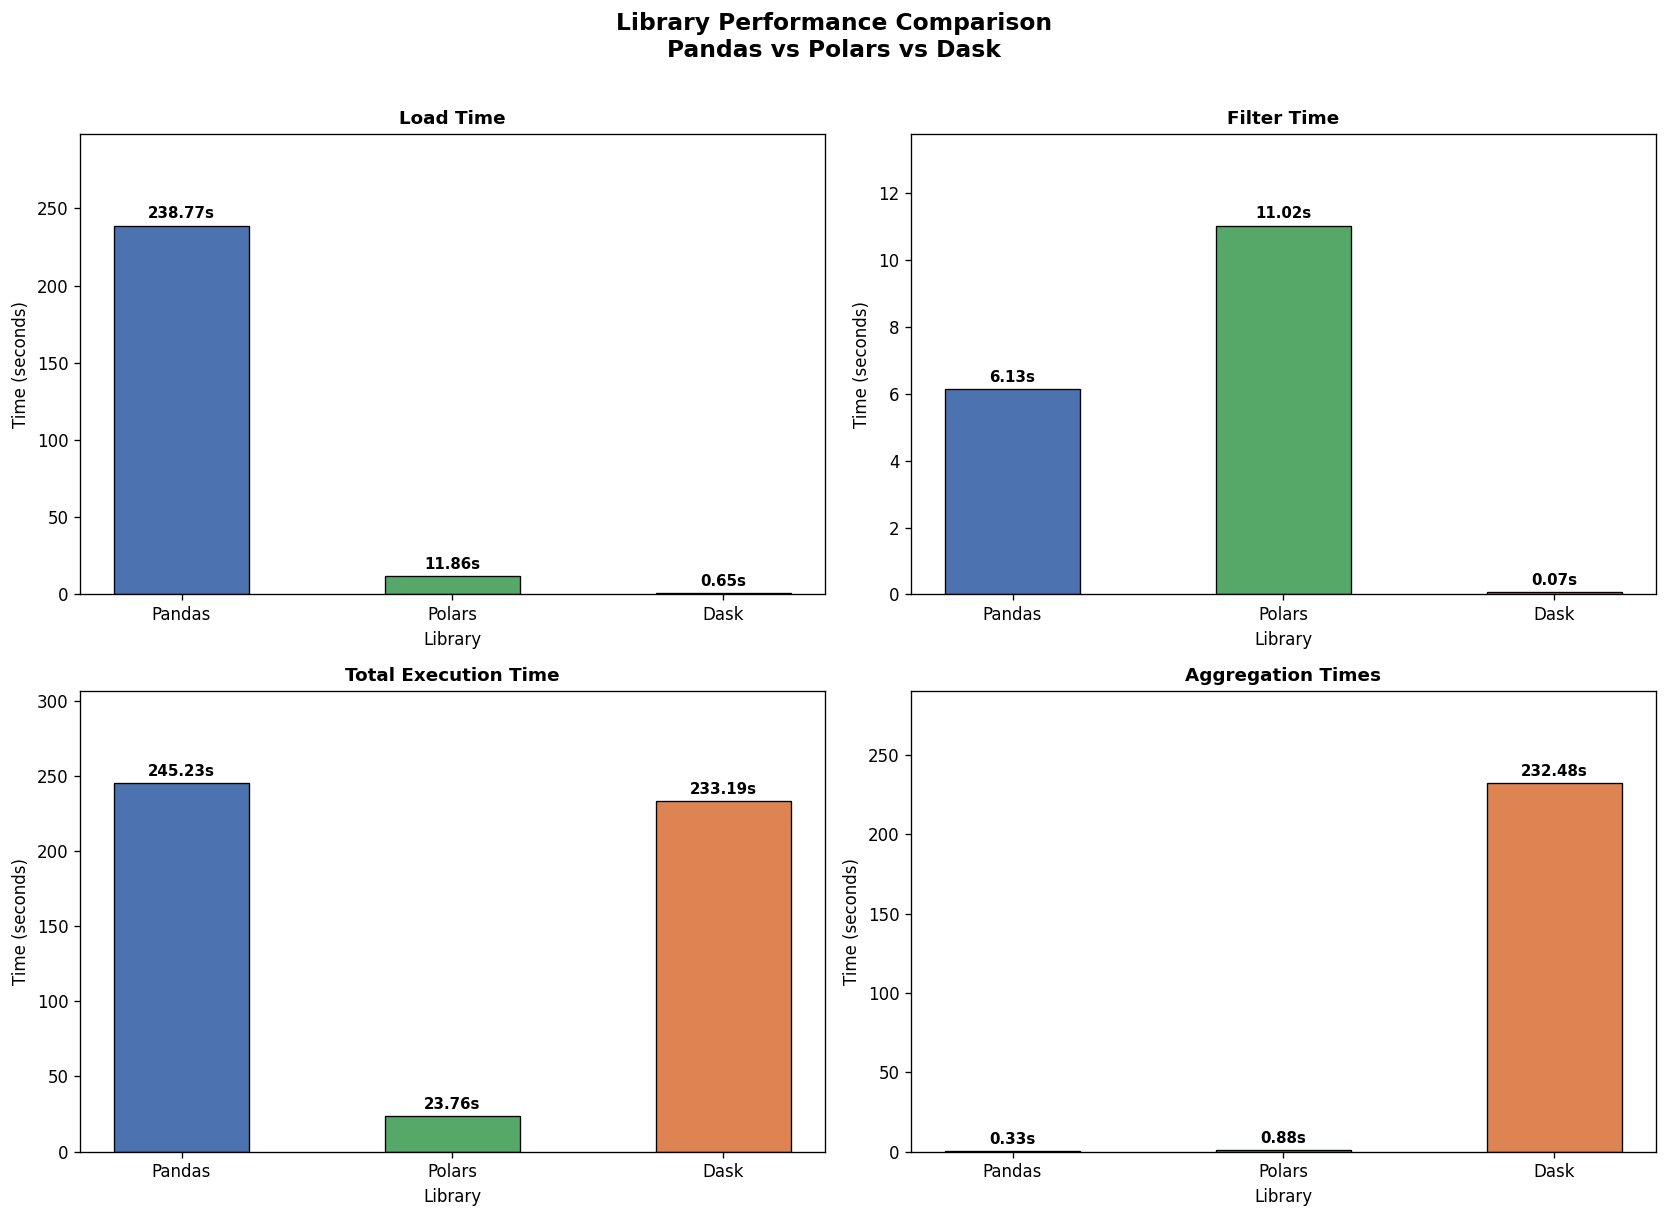

✅ Charts saved as comparison_charts.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
matplotlib.rcParams['figure.dpi'] = 120

# --- Data from our measurements ---
libraries = ['Pandas', 'Polars', 'Dask']
colors    = ['#4C72B0', '#55A868', '#DD8452']

load_times   = [pandas_load_time,   polars_load_time,   dask_load_time]
filter_times = [pandas_filter_time, polars_filter_time, dask_filter_time]
agg_times    = [pandas_count_time,  polars_count_time,  dask_count_time]
total_times  = [pandas_total_time,  polars_total_time,  dask_total_time]
memories     = [pandas_mem_mb,      polars_mem_mb,      dask_mem_mb]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Library Performance Comparison\nPandas vs Polars vs Dask', fontsize=14, fontweight='bold', y=1.01)

def add_bar(ax, vals, title, ylabel, unit='s'):
    bars = ax.bar(libraries, vals, color=colors, edgecolor='black', linewidth=0.8, width=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Library')
    ax.set_ylim(0, max(vals) * 1.25)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.02,
                f'{v:.2f}{unit}', ha='center', fontsize=9, fontweight='bold')

add_bar(axes[0,0], load_times,   'Load Time',          'Time (seconds)')
add_bar(axes[0,1], filter_times, 'Filter Time',        'Time (seconds)')
add_bar(axes[1,0], total_times,  'Total Execution Time','Time (seconds)')
add_bar(axes[1,1], agg_times, 'Aggregation Time','Time (seconds)')

plt.tight_layout()
plt.savefig('comparison_charts.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Charts saved as comparison_charts.png")

C:\Users\user\AppData\Local\Temp\ipykernel_1896\368631448.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
C:\Users\user\AppData\Local\Temp\ipykernel_1896\368631448.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
C:\Users\user\AppData\Local\Temp\ipykernel_1896\368631448.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
C:\Users\user\AppData\Local\Temp\ipykernel_1896\368631448.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.

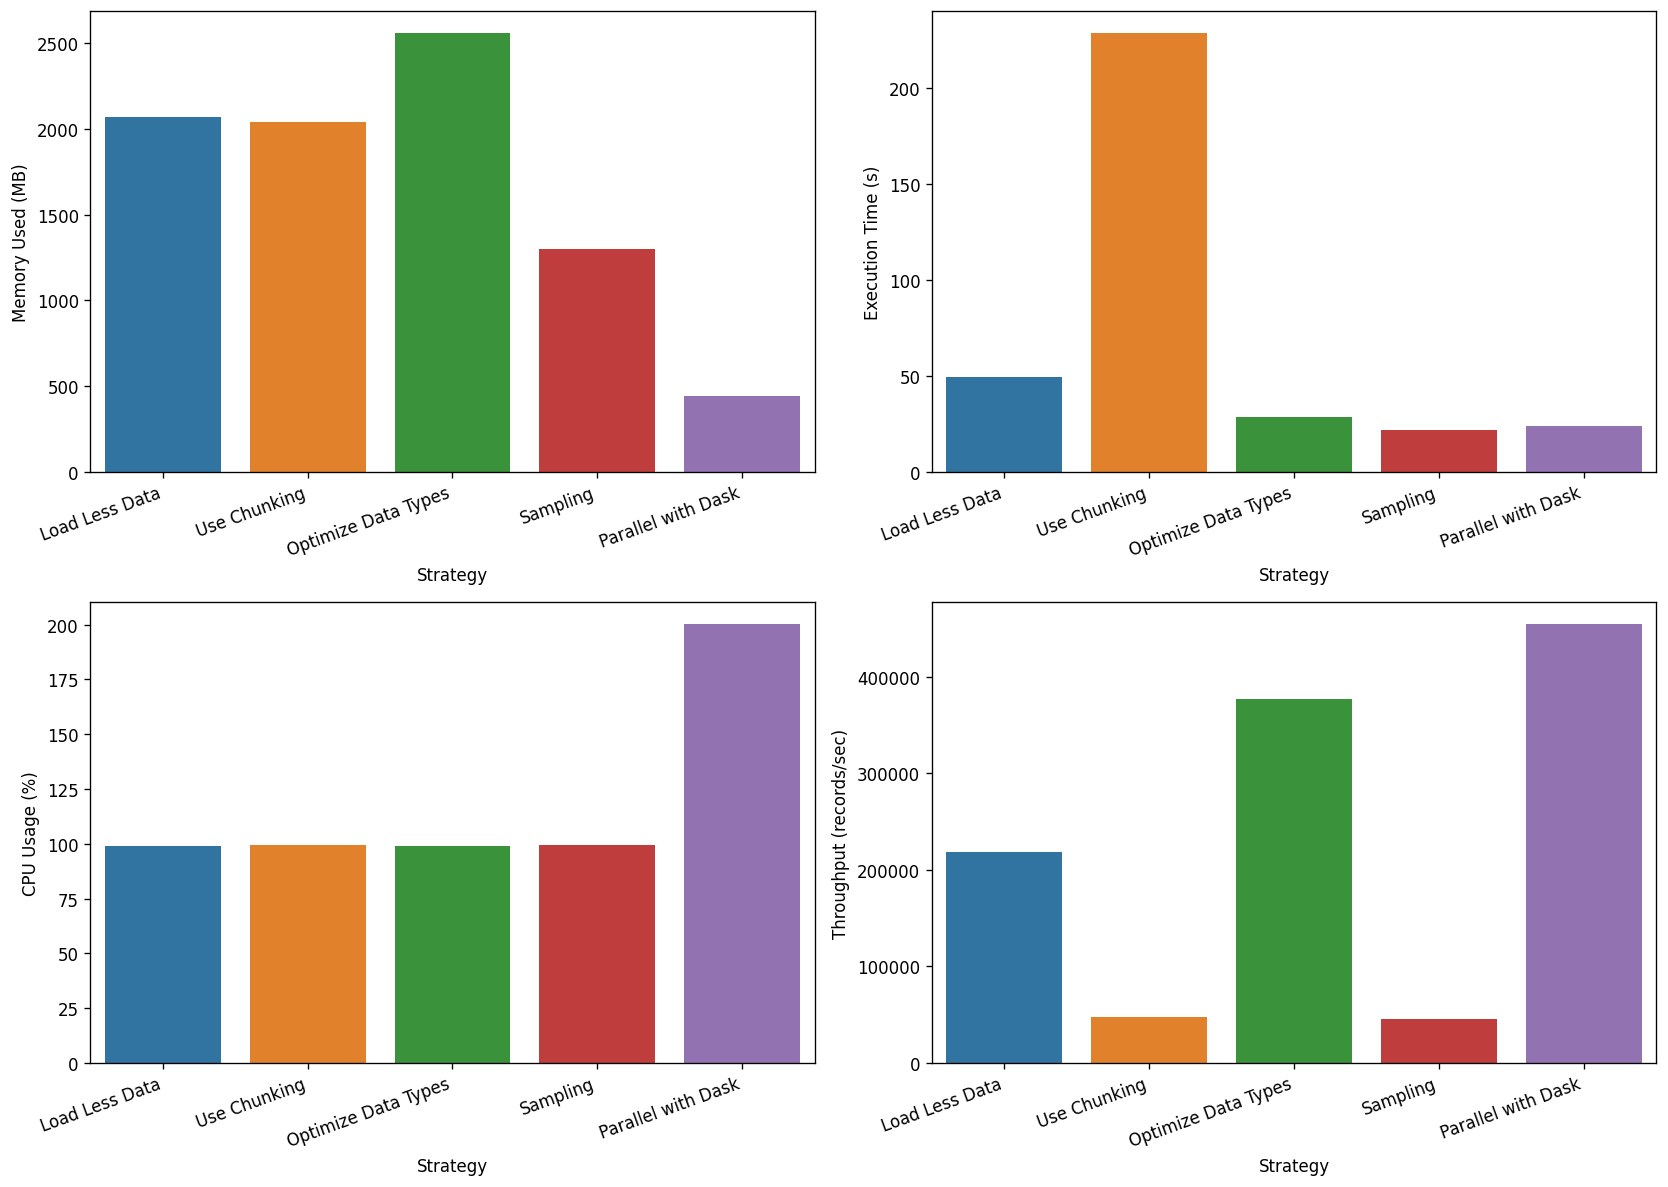

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data
strategies_data = pd.DataFrame({
    'Strategy': [
        'Load Less Data', 
        'Use Chunking', 
        'Optimize Data Types', 
        'Sampling', 
        'Parallel with Dask'
    ],
    'Memory Used (MB)': [
        2068.93,
        2039.30,
        2558.73,
        1300.22,
        443.41
    ],
    'Execution Time (s)': [
        49.51,
        228.67,
        28.67,
        21.81,
        23.76
    ],
    'CPU Usage (%)': [
        99.20,
        99.50,
        99.10,
        99.40,
        200.30
    ],
    'Throughput (records/sec)': [
        218219,
        47243,
        376795,
        45853,
        454726
    ]
})

# Function to add labels
def add_labels(ax, fmt="{:,.2f}"):
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(fmt.format(height),
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=9,
                    xytext=(0, 3),
                    textcoords='offset points')

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot charts
sns.barplot(x="Strategy", y="Memory Used (MB)", data=strategies_data, ax=axes[0, 0], hue="Strategy", legend=False)
sns.barplot(x="Strategy", y="Execution Time (s)", data=strategies_data, ax=axes[0, 1], hue="Strategy", legend=False)
sns.barplot(x="Strategy", y="CPU Usage (%)", data=strategies_data, ax=axes[1, 0], hue="Strategy", legend=False)
sns.barplot(x="Strategy", y="Throughput (records/sec)", data=strategies_data, ax=axes[1, 1], hue="Strategy", legend=False)

# Rotate x labels
for ax in axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')

# Add labels (custom format per chart)
add_labels(axes[0, 0], "{:,.0f}")  # Memory
add_labels(axes[0, 1], "{:,.2f}")  # Time
add_labels(axes[1, 0], "{:,.1f}")  # CPU
add_labels(axes[1, 1], "{:,.0f}")  # Throughput

plt.tight_layout()
plt.show()

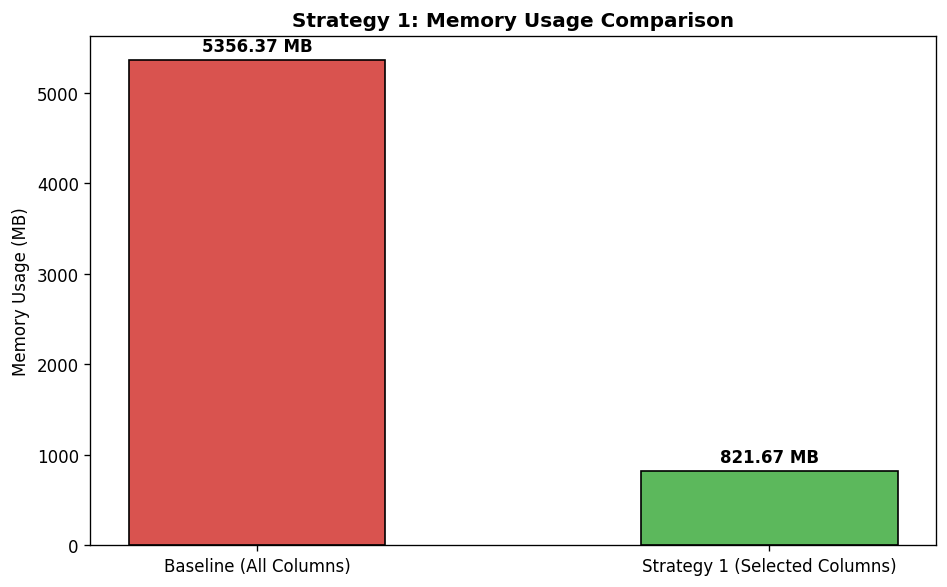

In [ ]:
# Section 1: Baseline vs Strategy 1 (Load Less Data)
import matplotlib.pyplot as plt

# Metrics extracted from notebook outputs
baseline_mem = 5356.37
opt_cols_mem = 821.67

labels = ['Baseline (All Columns)', 'Strategy 1 (Selected Columns)']
memory_vals = [baseline_mem, opt_cols_mem]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, memory_vals, color=['#d9534f', '#5cb85c'], width=0.5, edgecolor='black')
plt.title('Strategy 1: Memory Usage Comparison', fontsize=12, fontweight='bold')
plt.ylabel('Memory Usage (MB)')

for bar, val in zip(bars, memory_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f"{val} MB", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

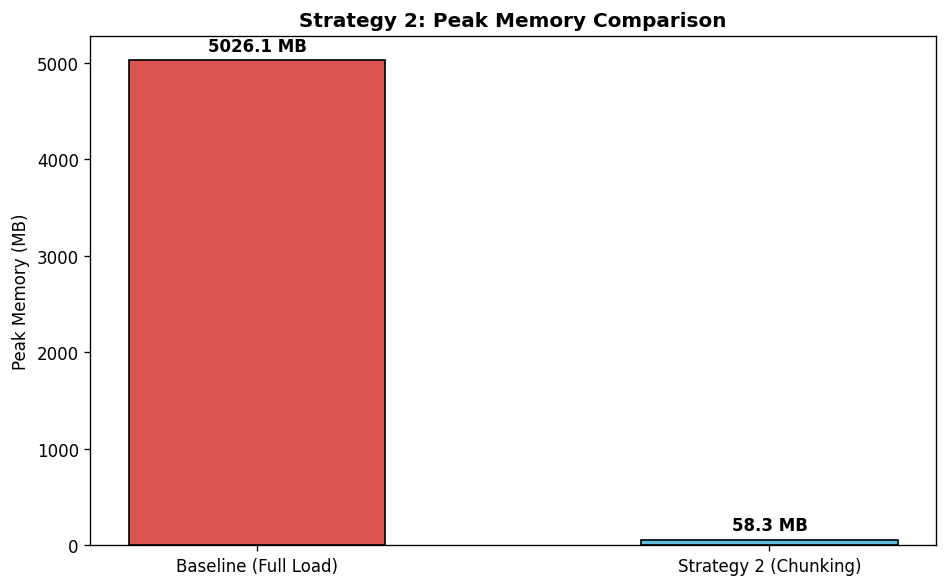

In [16]:
# Section 2: Baseline vs Strategy 2 (Chunking)
# Metrics extracted from notebook outputs
baseline_peak_mem = 5026.10
chunking_peak_mem = 58.30

labels = ['Baseline (Full Load)', 'Strategy 2 (Chunking)']
peak_vals = [baseline_peak_mem, chunking_peak_mem]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, peak_vals, color=['#d9534f', '#5bc0de'], width=0.5, edgecolor='black')
plt.title('Strategy 2: Peak Memory Comparison', fontsize=12, fontweight='bold')
plt.ylabel('Peak Memory (MB)')

for bar, val in zip(bars, peak_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f"{val} MB", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

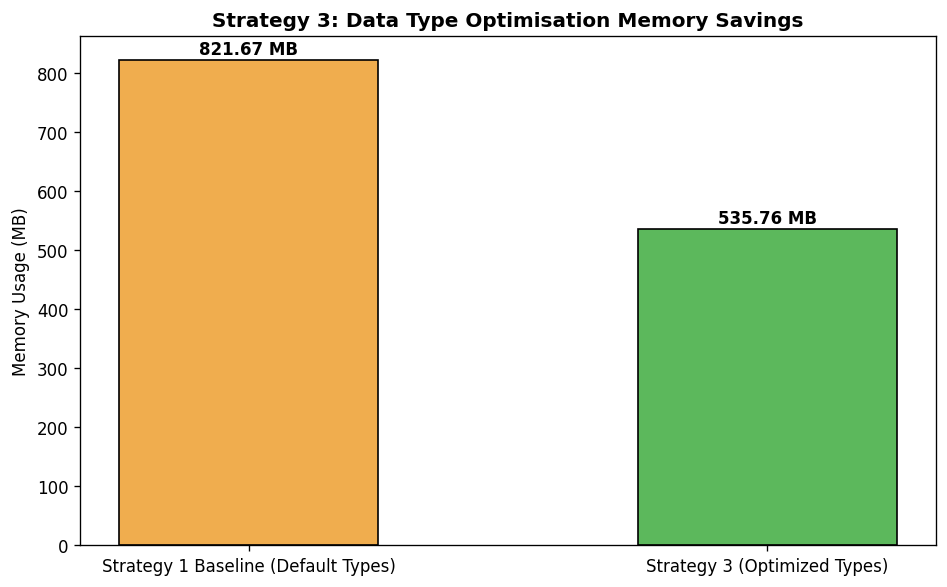

In [17]:
# Section 3: Baseline vs Strategy 3 (Data Type Optimisation)
# Metrics extracted from notebook outputs
default_types_mem = 821.67
opt_types_mem = 535.76

labels = ['Strategy 1 Baseline (Default Types)', 'Strategy 3 (Optimized Types)']
type_vals = [default_types_mem, opt_types_mem]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, type_vals, color=['#f0ad4e', '#5cb85c'], width=0.5, edgecolor='black')
plt.title('Strategy 3: Data Type Optimisation Memory Savings', fontsize=12, fontweight='bold')
plt.ylabel('Memory Usage (MB)')

for bar, val in zip(bars, type_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             f"{val} MB", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

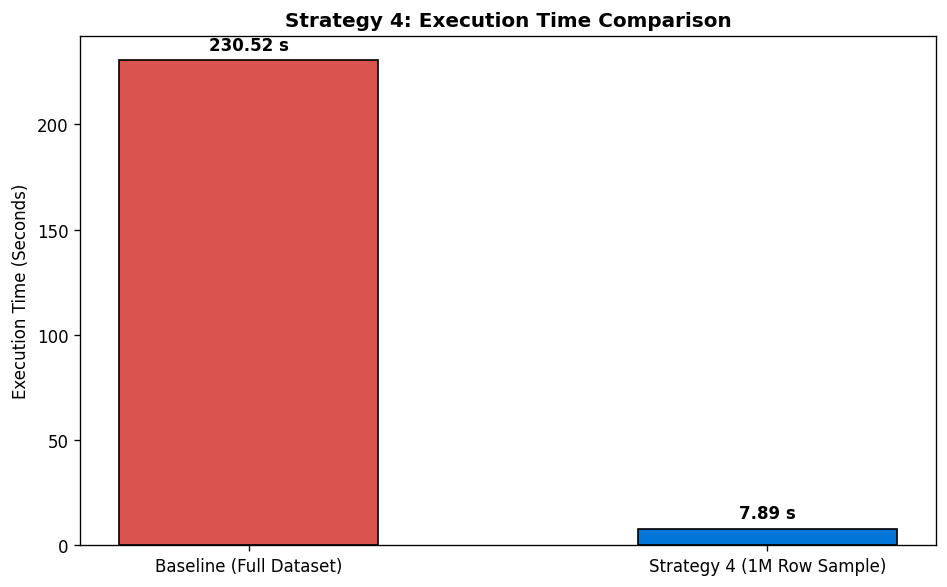

In [18]:
# Section 4: Baseline vs Strategy 4 (Sampling)
# Metrics extracted from notebook outputs
baseline_time = 230.52
sampling_time = 7.89

labels = ['Baseline (Full Dataset)', 'Strategy 4 (1M Row Sample)']
time_vals = [baseline_time, sampling_time]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, time_vals, color=['#d9534f', '#0275d8'], width=0.5, edgecolor='black')
plt.title('Strategy 4: Execution Time Comparison', fontsize=12, fontweight='bold')
plt.ylabel('Execution Time (Seconds)')

for bar, val in zip(bars, time_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f"{val} s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

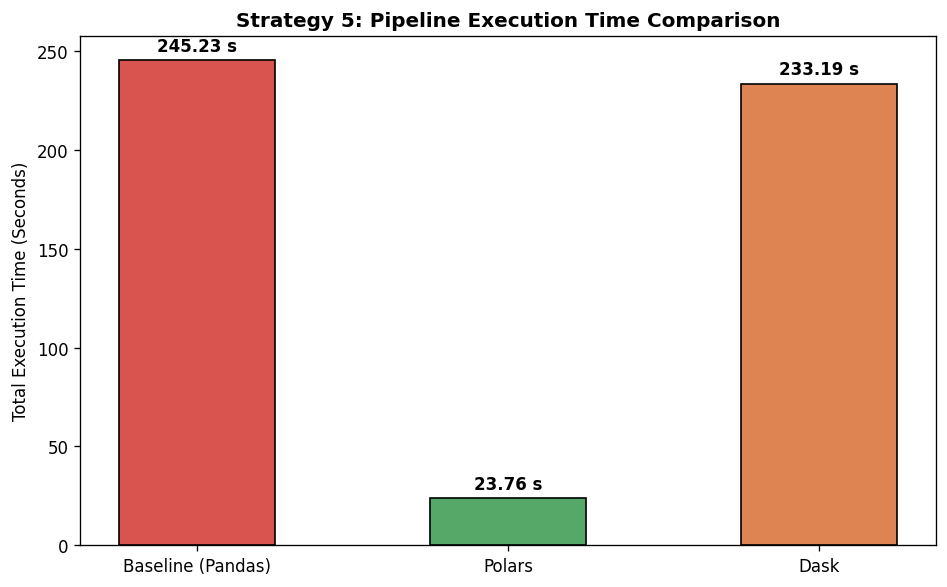

In [13]:
# Section 5: Baseline vs Strategy 5 (Parallel Processing)
labels = ['Baseline (Pandas)', 'Polars', 'Dask']
parallel_vals = [pandas_total_time, polars_total_time, dask_total_time]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, parallel_vals, color=['#d9534f', '#55A868', '#DD8452'], width=0.5, edgecolor='black')
plt.title('Strategy 5: Pipeline Execution Time Comparison', fontsize=12, fontweight='bold')
plt.ylabel('Total Execution Time (Seconds)')

for bar, val in zip(bars, parallel_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(parallel_vals)*0.02), 
             f"{val:.2f} s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

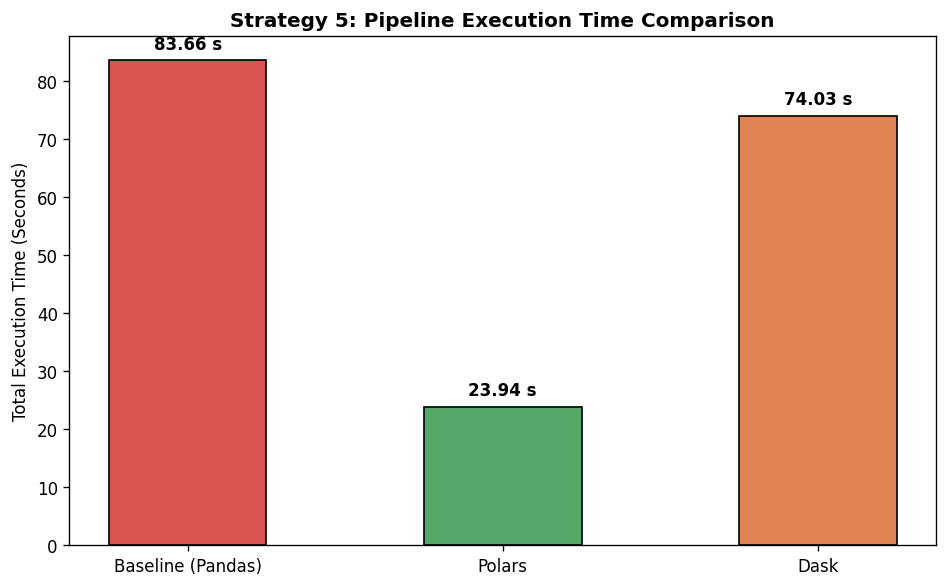

In [19]:
# Section 5: Baseline vs Strategy 5 (Parallel Processing)
# Metrics extracted from notebook outputs
pandas_time = 83.66
polars_time = 23.94
dask_time = 74.03

labels = ['Baseline (Pandas)', 'Polars', 'Dask']
parallel_vals = [pandas_time, polars_time, dask_time]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, parallel_vals, color=['#d9534f', '#55A868', '#DD8452'], width=0.5, edgecolor='black')
plt.title('Strategy 5: Pipeline Execution Time Comparison', fontsize=12, fontweight='bold')
plt.ylabel('Total Execution Time (Seconds)')

for bar, val in zip(bars, parallel_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f"{val} s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()